In [7]:
%pip install xgboost lightgbm catboost


Note: you may need to restart the kernel to use updated packages.


In [8]:
!python -m pip install --upgrade pip


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

In [73]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [128]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [129]:
empty_strings = (df['TotalCharges'].str.strip() == '').sum()
print(f"Пустых строк: {empty_strings}") 

Пустых строк: 11


In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [131]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [132]:
# 1 EDA
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [133]:
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7032.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3794.737500
max      72.000000      118.750000   8684.800000


In [ ]:
# Выводы:
# новые клиенты уходят чаще - медиана 29 мес, больше половины клиентов больше 2-х лет
# дорогие тарифы могут быть причиной ухода, платежи от 18 до 118

In [134]:
print("Корреляционная матрица")
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
if 'TotalCharges' in df.columns:
    print(df[numeric_cols].corr())

Корреляционная матрица
                 tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000


In [135]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100

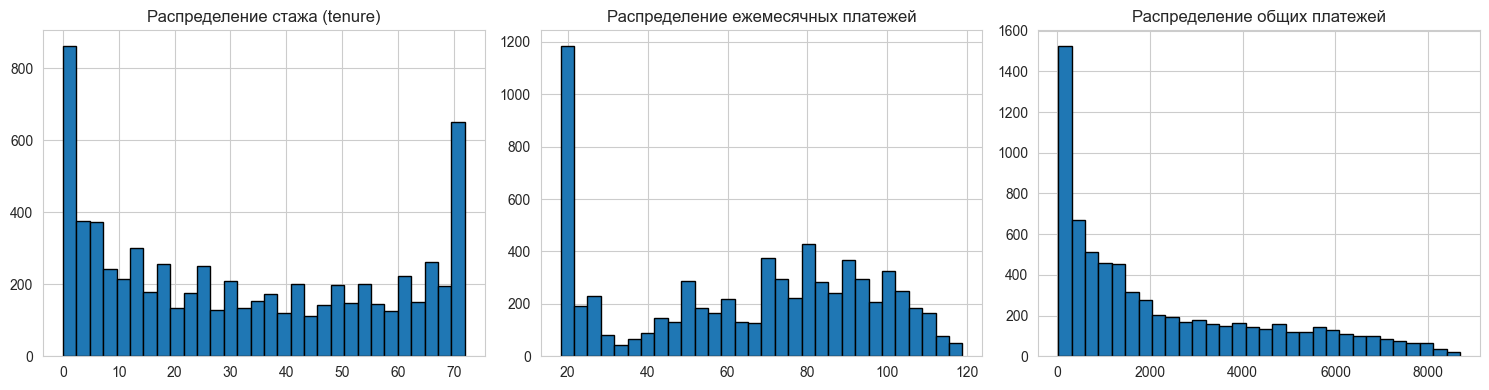

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['tenure'].hist(ax=axes[0], bins=30, edgecolor='black')
axes[0].set_title('Распределение стажа (tenure)')
df['MonthlyCharges'].hist(ax=axes[1], bins=30, edgecolor='black')
axes[1].set_title('Распределение ежемесячных платежей')
df['TotalCharges'].hist(ax=axes[2], bins=30, edgecolor='black')
axes[2].set_title('Распределение общих платежей')
plt.tight_layout()
plt.show()

In [138]:
tenure_bins = [0, 6, 12, 24, 36, 48, 60, 72]
tenure_labels = ['0-6 мес', '6-12 мес', '1-2 года', '2-3 года', '3-4 года', '4-5 лет', '5-6 лет']
df['tenure_group'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels)

tenure_dist = df['tenure_group'].value_counts().sort_index()
tenure_pct = df['tenure_group'].value_counts(normalize=True).sort_index() * 100

tenure_table = pd.DataFrame({
    'Количество клиентов': tenure_dist,
    'Доля, %': tenure_pct.round(1)
})
print(tenure_table)

              Количество клиентов  Доля, %
tenure_group                              
0-6 мес                      1470     20.9
6-12 мес                      705     10.0
1-2 года                     1024     14.6
2-3 года                      832     11.8
3-4 года                      762     10.8
4-5 лет                       832     11.8
5-6 лет                      1407     20.0


In [139]:
charges_bins = [0, 30, 50, 70, 90, 120]
charges_labels = ['0-30$', '30-50$', '50-70$', '70-90$', '90-120$']
df['charges_group'] = pd.cut(df['MonthlyCharges'], bins=charges_bins, labels=charges_labels)

charges_dist = df['charges_group'].value_counts().sort_index()
charges_pct = df['charges_group'].value_counts(normalize=True).sort_index() * 100

charges_table = pd.DataFrame({
    'Количество клиентов': charges_dist,
    'Доля, %': charges_pct.round(1)
})
print(charges_table)

               Количество клиентов  Доля, %
charges_group                              
0-30$                         1653     23.5
30-50$                         646      9.2
50-70$                        1161     16.5
70-90$                        1844     26.2
90-120$                       1739     24.7


In [140]:
total_bins = [0, 500, 1000, 2000, 3000, 5000, 10000]
total_labels = ['0-500$', '500-1000$', '1000-2000$', '2000-3000$', '3000-5000$', '5000-10000$']
df['total_group'] = pd.cut(df['TotalCharges'], bins=total_bins, labels=total_labels)

total_dist = df['total_group'].value_counts().sort_index()
total_pct = df['total_group'].value_counts(normalize=True).sort_index() * 100

total_table = pd.DataFrame({
    'Количество клиентов': total_dist,
    'Доля, %': total_pct.round(1)
})
print(total_table)

             Количество клиентов  Доля, %
total_group                              
0-500$                      2000     28.4
500-1000$                    893     12.7
1000-2000$                  1283     18.2
2000-3000$                   652      9.3
3000-5000$                  1069     15.2
5000-10000$                 1135     16.1


In [141]:
internet_charges = df.groupby('InternetService')['MonthlyCharges'].describe()
print(internet_charges.round(2))

                  count   mean    std    min    25%    50%     75%     max
InternetService                                                           
DSL              2421.0  58.10  16.26  23.45  46.20  56.15   69.90   94.80
Fiber optic      3096.0  91.50  12.66  67.75  80.55  91.68  101.15  118.75
No               1526.0  21.08   2.16  18.25  19.70  20.15   20.90   26.90


In [142]:
pivot_table = pd.pivot_table(
    df, 
    values='MonthlyCharges', 
    index='InternetService', 
    columns='Contract', 
    aggfunc='mean'
).round(2)
print(pivot_table)

Contract         Month-to-month  One year  Two year
InternetService                                    
DSL                       50.22     61.40     70.46
Fiber optic               87.02     98.78    104.57
No                        20.41     20.82     21.78


In [83]:
senior_stats = df['SeniorCitizen'].value_counts(normalize=True) * 100
print(f"Пенсионеры: {senior_stats.get(1, 0):.1f}%")
print(f"Не пенсионеры: {senior_stats.get(0, 0):.1f}%")

Пенсионеры: 16.2%
Не пенсионеры: 83.8%


In [84]:
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
print(senior_churn)

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


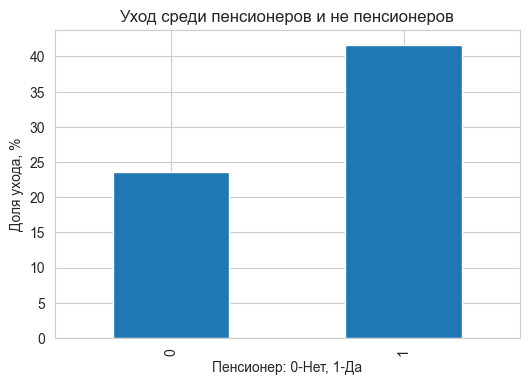

In [149]:
plt.figure(figsize=(6, 4))
senior_churn['Yes'].plot(kind='bar')
plt.title('Уход среди пенсионеров и не пенсионеров')
plt.xlabel('Пенсионер: 0-Нет, 1-Да')
plt.ylabel('Доля ухода, %')
plt.show()

In [143]:
print(f"Доля клиентов, которые ушли (Churn = Yes): {churn_counts.get('Yes', 0):.1f}%")
print(f"Доля лояльных клиентов (Churn = No): {churn_counts.get('No', 0):.1f}%")

Доля клиентов, которые ушли (Churn = Yes): 26.5%
Доля лояльных клиентов (Churn = No): 73.5%


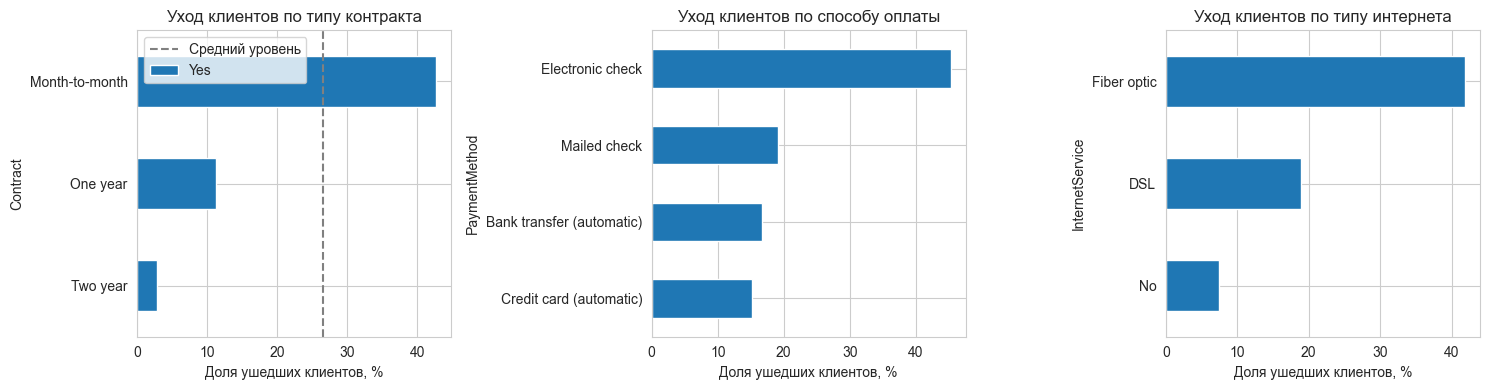

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График 1: Тип контракта 
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn['Yes'].sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Уход клиентов по типу контракта')
axes[0].set_xlabel('Доля ушедших клиентов, %')
axes[0].axvline(x=churn_counts.get('Yes', 0), linestyle='--', color='gray', label='Средний уровень')
axes[0].legend()

# График 2: Способ оплаты
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn['Yes'].sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Уход клиентов по способу оплаты')
axes[1].set_xlabel('Доля ушедших клиентов, %')

# График 3: Наличие интернет-услуг
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn['Yes'].sort_values().plot(kind='barh', ax=axes[2])
axes[2].set_title('Уход клиентов по типу интернета')
axes[2].set_xlabel('Доля ушедших клиентов, %')
plt.tight_layout()
plt.show()

In [ ]:
# Выводы общие по EDA:
# 1 - два типа клиентов: бюджетные (23.5%) и премиум (26.2% + 24.7% = 50.9%)
# 2 - чаще уходят - пенсионеры с Fiber optic + Month-to-month контрактом
# 3 - реже уходят - не пенсионеры без интернета + с долгим контрактом

In [89]:
# 2 Preprocessing / Feature Engineering
df.drop('customerID', axis=1, inplace=True)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [90]:
df.dropna(subset=['TotalCharges'], inplace=True)

# новый признак - средняя стоимость обслуживания в месяц - Общие расходы/ кол-во месяцев
df['Average_Service_Cost'] = df['TotalCharges'] / (df['tenure'] + 1e-9)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Average_Service_Cost
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,55.573529
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,82.937500
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,102.262500
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,31.495455
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,76.650000


In [91]:
# 3 Кодирование категориальных признаков и разбиение
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [92]:
# Разбиваем на train и test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [93]:
# Применим LabelEncoder к категориальным колонкам
categorical_cols = X_train.select_dtypes(include=['object', 'str']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

In [94]:
# 4 БИТВА АЛГОРИТМОВ
models = {
    "1. Sklearn GBM": GradientBoostingClassifier(random_state=42),
    "2. XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "3. LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "4. CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

results_default = []

for name, model in models.items():
    # Обучаем
    model.fit(X_train, y_train)
    # Предсказываем вероятности для ROC-AUC
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    # Предсказываем классы для Accuracy
    y_pred = model.predict(X_test)
    
    # Оцениваем
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    
    results_default.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': auc})
    print(f"{name} -> Accuracy: {acc:.4f}, ROC-AUC: {auc:.4f}")

1. Sklearn GBM -> Accuracy: 0.7974, ROC-AUC: 0.8382
2. XGBoost -> Accuracy: 0.7669, ROC-AUC: 0.8079
3. LightGBM -> Accuracy: 0.7875, ROC-AUC: 0.8273
4. CatBoost -> Accuracy: 0.7854, ROC-AUC: 0.8257


In [95]:
df_default = pd.DataFrame(results_default).sort_values('ROC-AUC', ascending=False)
print(df_default.to_string(index=False))

         Model  Accuracy  ROC-AUC
1. Sklearn GBM  0.797441 0.838216
   3. LightGBM  0.787491 0.827333
   4. CatBoost  0.785359 0.825673
    2. XGBoost  0.766880 0.807892


In [96]:
# 5 Настройка гиперпараметров

param_grid_sklearn = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

param_grid_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

param_grid_cat = {
    'iterations': [100, 200],
    'depth': [3, 6],
    'learning_rate': [0.05, 0.1]
}


In [97]:
sklearn_model = GradientBoostingClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
lgb_model = LGBMClassifier(random_state=42, verbose=-1)
cat_model = CatBoostClassifier(random_state=42, verbose=0)

In [98]:
grid_search_sklearn = GridSearchCV(sklearn_model, param_grid_sklearn, scoring='roc_auc', cv=3, n_jobs=-1)
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, scoring='roc_auc', cv=3, n_jobs=-1, verbose=0)
grid_search_lgb = GridSearchCV(lgb_model, param_grid_lgb, scoring='roc_auc', cv=3, n_jobs=-1, verbose=0)
grid_search_cat = GridSearchCV(cat_model, param_grid_cat, scoring='roc_auc', cv=3, n_jobs=-1, verbose=0)

In [105]:
grid_search_sklearn.fit(X_train, y_train)
best_sklearn = grid_search_sklearn.best_estimator_
print(f"Лучшие параметры для Sklearn GBM: {grid_search_sklearn.best_params_}")
y_pred_proba_sklearn = best_sklearn.predict_proba(X_test)[:, 1]
auc_sklearn = roc_auc_score(y_test, y_pred_proba_sklearn)
print(f"ROC-AUC: {auc_sklearn:.4f}")

Лучшие параметры для Sklearn GBM: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
ROC-AUC: 0.8373


In [106]:
grid_search_xgb.fit(X_train, y_train)
best_xgb = grid_search_xgb.best_estimator_
print(f"Лучшие параметры: {grid_search_xgb.best_params_}")
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"ROC-AUC: {auc_xgb:.4f}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
ROC-AUC: 0.8392


In [107]:
grid_search_lgb.fit(X_train, y_train)
best_lgb = grid_search_lgb.best_estimator_
print(f"Лучшие параметры: {grid_search_lgb.best_params_}")
y_pred_proba_lgb = best_lgb.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print(f"ROC-AUC: {auc_lgb:.4f}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
ROC-AUC: 0.8391


In [108]:
grid_search_cat.fit(X_train, y_train)
best_cat = grid_search_cat.best_estimator_
print(f"Лучшие параметры: {grid_search_cat.best_params_}")
y_pred_proba_cat = best_cat.predict_proba(X_test)[:, 1]
auc_cat = roc_auc_score(y_test, y_pred_proba_cat)
print(f"ROC-AUC: {auc_cat:.4f}")

Лучшие параметры: {'depth': 3, 'iterations': 200, 'learning_rate': 0.05}
ROC-AUC: 0.8372


In [109]:
results = pd.DataFrame([
    {'Model': 'Sklearn GBM (tuned)', 'ROC-AUC': auc_sklearn},
    {'Model': 'XGBoost', 'ROC-AUC': auc_xgb},
    {'Model': 'LightGBM', 'ROC-AUC': auc_lgb},
    {'Model': 'CatBoost', 'ROC-AUC': auc_cat}
]).sort_values('ROC-AUC', ascending=False)

print(results.to_string(index=False))
win = results.iloc[0]

print(f"\n Лучшая модель: {win['Model']}")


              Model  ROC-AUC
            XGBoost 0.839192
           LightGBM 0.839058
Sklearn GBM (tuned) 0.837306
           CatBoost 0.837192

 Лучшая модель: XGBoost
